# 01 EDA

Primero miro como viene el dataset y que cosas pueden dar problemas antes de modelar.


## Que voy a revisar

- Tamano del dataset y tipos de columnas.
- Nulos, duplicados y valores raros escritos como texto.
- Distribucion de la variable objetivo.
- Posibles problemas con variables academicas y notas igual a cero.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocess_base import (
    cargar_data,
    limpieza_basica,
    tratar_ceros_notas_sin_evaluacion,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

In [2]:
df = cargar_data()
df_limpio = limpieza_basica(df)

print("Shape original:", df.shape)
print("Numero de columnas:", df.shape[1])
df.head()

Shape original: (4424, 37)
Numero de columnas: 37
Out[2]: 
  estado_civil                         modo_solicitud  orden_solicitud  \
0    soltero/a            2a_fase_contingente_general                5   
1    soltero/a  estudiante_internacional_licenciatura                1   
2    soltero/a            1a_fase_contingente_general                5   
3    soltero/a            2a_fase_contingente_general                2   
4     casado/a                       mayor_de_23_anos                1   

                           curso asistencia_diurna_vespertina  \
0  animacion_y_diseno_multimedia                       diurna   
1                        turismo                       diurna   
2         diseno_de_comunicacion                       diurna   
3      periodismo_y_comunicacion                       diurna   
4       servicio_social_nocturno                   vespertina   

   cualificacion_previa  nota_cualificacion_previa nacionalidad  \
0  educacion_secundaria               

## Estructura general

El dataset tiene 4424 filas y 37 columnas. Mezcla datos personales, administrativos, economicos y notas del primer y segundo semestre.


In [3]:
resumen_tipos = (
    df_limpio.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="n_columnas")
)

display(resumen_tipos)
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   estado_civil                       4424 non-null   object 
 1   modo_solicitud                     4424 non-null   object 
 2   orden_solicitud                    4424 non-null   int64  
 3   curso                              4424 non-null   object 
 4   asistencia_diurna_vespertina       4424 non-null   object 
 5   cualificacion_previa               4424 non-null   object 
 6   nota_cualificacion_previa          4424 non-null   float64
 7   nacionalidad                       4424 non-null   object 
 8   cualificacion_madre                4424 non-null   object 
 9   cualificacion_padre                4424 non-null   object 
 10  ocupacion_madre                    4407 non-null   object 
 11  ocupacion_padre                    4405 non-null   objec

,dtype,n_columnas
0,object,18
1,int64,12
2,float64,7


In [4]:
total_nulls = int(df.isna().sum().sum())
duplicated_rows = int(df.duplicated().sum())

pd.DataFrame(
    {
        "metrica": ["nulos_nativos", "filas_duplicadas"],
        "valor": [total_nulls, duplicated_rows],
    }
)

Out[4]: 
            metrica  valor
0     nulos_nativos      0
1  filas_duplicadas      0


## Nulos y duplicados

No aparecen nulos nativos ni filas duplicadas. El problema esta mas en valores tipo `en_blanco` o `desconocido`, que pueden actuar como missing.


,frecuencia,porcentaje
objetivo,,
graduado,2209,49.93
abandono,1421,32.12
matriculado,794,17.95


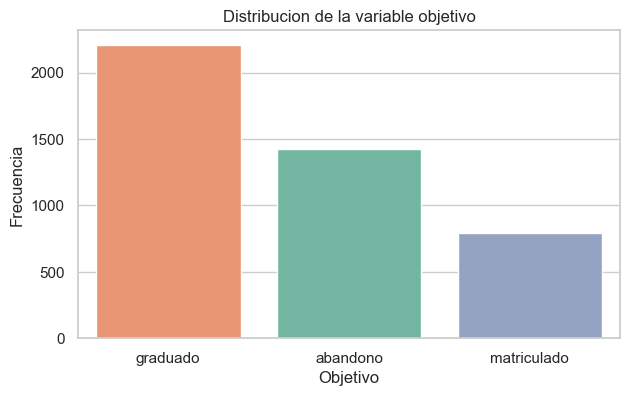

In [5]:
target_counts = df_limpio["objetivo"].value_counts().rename("frecuencia")
target_pct = df_limpio["objetivo"].value_counts(normalize=True).mul(100).round(2).rename("porcentaje")
target_summary = pd.concat([target_counts, target_pct], axis=1)
display(target_summary)

plt.figure(figsize=(7, 4))
sns.countplot(
    data=df_limpio,
    x="objetivo",
    order=target_counts.index,
    hue="objetivo",
    palette="Set2",
    legend=False,
)
plt.title("Distribucion de la variable objetivo")
plt.xlabel("Objetivo")
plt.ylabel("Frecuencia")
plt.show()

## Variable objetivo

La clase mas frecuente es `graduado`, luego `abandono` y por ultimo `matriculado`. No es un desbalance extremo, pero en clasificacion no conviene mirar solo accuracy.


In [6]:
def count_special_values(df, values=("en_blanco", "desconocido")):
    filas = []
    for col in df.columns:
        if df[col].dtype == "object":
            for value in values:
                count = int((df[col] == value).sum())
                if count > 0:
                    filas.append({"columna": col, "valor": value, "frecuencia": count})
    return pd.DataFrame(filas).sort_values(["valor", "frecuencia"], ascending=[True, False])

special_values = count_special_values(df)
display(special_values)

,columna,valor,frecuencia
0,cualificacion_madre,desconocido,130
1,cualificacion_padre,desconocido,112
3,ocupacion_padre,en_blanco,19
2,ocupacion_madre,en_blanco,17


## Valores especiales

Aparecen dos valores que reviso aparte:

- `en_blanco` en ocupacion de madre y padre.
- `desconocido` en cualificacion de madre y padre.

No los trato igual porque no significan necesariamente lo mismo.


In [7]:
cols_en_blanco = ["ocupacion_madre", "ocupacion_padre"]

for col in cols_en_blanco:
    mask = df[col].eq("en_blanco")
    print(f"\nDistribucion de objetivo cuando {col} = 'en_blanco':")
    display(df.loc[mask, "objetivo"].value_counts(normalize=True).mul(100).round(2))


Distribucion de objetivo cuando ocupacion_madre = 'en_blanco':

Distribucion de objetivo cuando ocupacion_padre = 'en_blanco':


objetivo
abandono       76.47
graduado       11.76
matriculado    11.76
Name: proportion, dtype: float64

objetivo
abandono       68.42
graduado       21.05
matriculado    10.53
Name: proportion, dtype: float64

## Caso `en_blanco`

En las pocas filas con `en_blanco` hay bastante abandono. Por eso no quiero dejarlo como una ocupacion normal, pero tampoco quiero borrar esas filas.


In [8]:
categorical_cols = df_limpio.select_dtypes(include="object").columns.tolist()
cardinalidad = (
    df_limpio[categorical_cols]
    .nunique(dropna=False)
    .sort_values(ascending=False)
    .rename("n_categorias")
    .reset_index()
    .rename(columns={"index": "columna"})
)
display(cardinalidad)

,columna,n_categorias
0,ocupacion_padre,46
1,cualificacion_padre,34
2,ocupacion_madre,32
3,cualificacion_madre,29
4,nacionalidad,21
5,modo_solicitud,18
6,cualificacion_previa,17
7,curso,17
8,estado_civil,6
9,objetivo,3


## Cardinalidad

Algunas categoricas tienen muchas categorias, sobre todo ocupaciones, cualificaciones y nacionalidad. Agrupar categorias raras podria ayudar, pero lo dejo como mejora y no como limpieza base.


In [9]:
macro_cols = ["tasa_desempleo", "tasa_inflacion", "pib"]
macro_combos = df_limpio[macro_cols].drop_duplicates().sort_values(macro_cols).reset_index(drop=True)
print("Numero de combinaciones macroeconomicas unicas:", len(macro_combos))
macro_combos

Numero de combinaciones macroeconomicas unicas: 10
Out[9]: 
   tasa_desempleo  tasa_inflacion   pib
0             7.6             2.6  0.32
1             8.9             1.4  3.51
2             9.4            -0.8 -3.12
3            10.8             1.4  1.74
4            11.1             0.6  2.02
5            12.4             0.5  1.79
6            12.7             3.7 -1.70
7            13.9            -0.3  0.79
8            15.5             2.8 -4.06
9            16.2             0.3 -0.92


## Variables macroeconomicas

Las variables macroeconomicas solo tienen 10 combinaciones distintas. Esto puede estar relacionado con cohortes o anos de entrada, asi que lo tengo en cuenta al interpretar resultados.


In [10]:
checks = []

for sem in [1, 2]:
    mat = df_limpio[f"asignaturas_{sem}sem_matriculadas"]
    conv = df_limpio[f"asignaturas_{sem}sem_convalidadas"]
    eva = df_limpio[f"asignaturas_{sem}sem_evaluadas"]

    iguales = int(((mat + conv) == eva).sum())
    mayores = int((eva > mat).sum())
    checks.append(
        {
            "semestre": f"{sem}sem",
            "coinciden_matriculadas_mas_convalidadas_con_evaluadas": iguales,
            "porcentaje_coincidencia": round(100 * iguales / len(df_limpio), 2),
            "casos_evaluadas_mayor_que_matriculadas": mayores,
        }
    )

pd.DataFrame(checks)

Out[10]: 
  semestre  coinciden_matriculadas_mas_convalidadas_con_evaluadas  \
0     1sem                                               1362       
1     2sem                                               1437       

   porcentaje_coincidencia  casos_evaluadas_mayor_que_matriculadas  
0                    30.79                                    2792  
1                    32.48                                    2660  


## Variables academicas

La relacion `matriculadas + convalidadas = evaluadas` no se cumple en la mayoria de filas. Ademas, hay muchos casos con `evaluadas > matriculadas`.

Por eso no corrijo ni elimino esas filas. Parece mas un tema de definicion de la variable que un error puntual.


In [11]:
resumen_ceros = []

for sem in [1, 2]:
    nota_col = f"nota_media_{sem}sem"
    eval_col = f"asignaturas_{sem}sem_evaluadas"
    mask_zero = df_limpio[nota_col].eq(0)
    mask_eval_zero = df_limpio[eval_col].eq(0)

    resumen_ceros.append(
        {
            "semestre": f"{sem}sem",
            "notas_iguales_a_0": int(mask_zero.sum()),
            "nota_0_y_evaluadas_0": int((mask_zero & mask_eval_zero).sum()),
            "nota_0_y_evaluadas_mayor_0": int((mask_zero & ~mask_eval_zero).sum()),
        }
    )

pd.DataFrame(resumen_ceros)

Out[11]: 
  semestre  notas_iguales_a_0  nota_0_y_evaluadas_0  \
0     1sem                718                   349   
1     2sem                870                   401   

   nota_0_y_evaluadas_mayor_0  
0                         369  
1                         469  


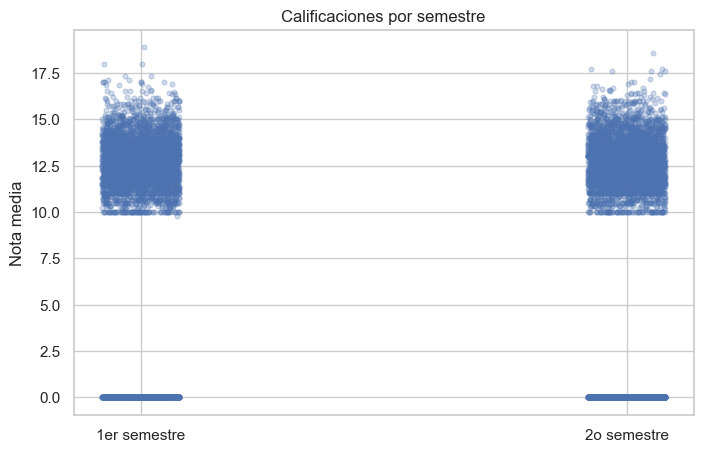

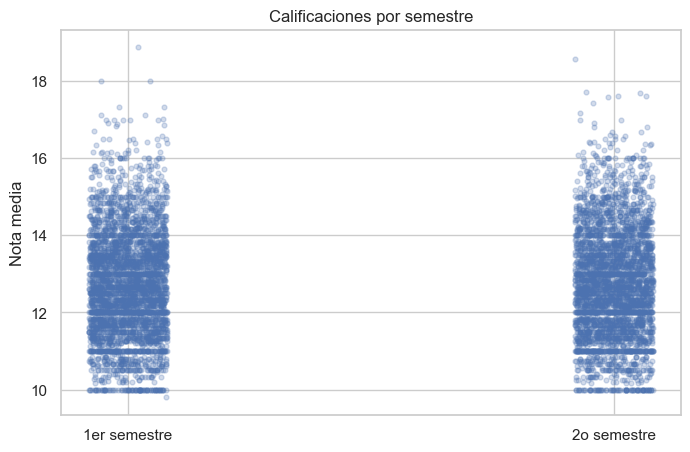

In [12]:
def plot_calificaciones_semestres(df, incluir_ceros=True):
    columnas = ["nota_media_1sem", "nota_media_2sem"]
    plot_df = df[columnas].copy()

    if not incluir_ceros:
        plot_df = plot_df.replace(0, np.nan)

    long_df = (
        plot_df.melt(var_name="semestre", value_name="nota")
        .dropna()
        .reset_index(drop=True)
    )
    long_df["x"] = long_df["semestre"].map({"nota_media_1sem": 0, "nota_media_2sem": 1})
    rng = np.random.default_rng(42)
    long_df["x_jitter"] = long_df["x"] + rng.uniform(-0.08, 0.08, size=len(long_df))

    plt.figure(figsize=(8, 5))
    plt.scatter(long_df["x_jitter"], long_df["nota"], alpha=0.25, s=12)
    plt.xticks([0, 1], ["1er semestre", "2o semestre"])
    plt.ylabel("Nota media")
    plt.title("Calificaciones por semestre")
    plt.show()

plot_calificaciones_semestres(df_limpio, incluir_ceros=True)
plot_calificaciones_semestres(df_limpio, incluir_ceros=False)

## Notas igual a cero

No todos los ceros significan lo mismo. Si la nota es 0 y tambien hay 0 evaluaciones, lo trato como nota no disponible. Si hay evaluaciones, mantengo el 0.


In [13]:
df_ceros_tratados = tratar_ceros_notas_sin_evaluacion(df_limpio)

comparacion_nan = pd.DataFrame(
    {
        "na_antes": df_limpio[["nota_media_1sem", "nota_media_2sem"]].isna().sum(),
        "na_despues": df_ceros_tratados[["nota_media_1sem", "nota_media_2sem"]].isna().sum(),
    }
)
comparacion_nan["nuevos_na"] = comparacion_nan["na_despues"] - comparacion_nan["na_antes"]
comparacion_nan

Out[13]: 
                 na_antes  na_despues  nuevos_na
nota_media_1sem         0         349        349
nota_media_2sem         0         401        401


## Outliers

No elimino outliers de forma automatica. Primero prefiero ver si son imposibles o simplemente valores poco frecuentes.


,columna,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
8,nota_media_2sem,11.285714,13.5,2.214286,7.964286,16.821429,480,11.93
0,edad_al_matricularse,19.000000,25.0,6.000000,10.000000,34.000000,441,9.97
3,asignaturas_1sem_matriculadas,5.000000,7.0,2.000000,2.000000,10.000000,424,9.58
5,nota_media_1sem,11.428571,13.5,2.071429,8.321429,16.607143,387,9.50
6,asignaturas_2sem_matriculadas,5.000000,7.0,2.000000,2.000000,10.000000,369,8.34
2,nota_cualificacion_previa,125.000000,140.0,15.000000,102.500000,162.500000,179,4.05
4,asignaturas_1sem_evaluadas,6.000000,10.0,4.000000,0.000000,16.000000,158,3.57
7,asignaturas_2sem_evaluadas,6.000000,10.0,4.000000,0.000000,16.000000,109,2.46
1,nota_admision,117.900000,134.8,16.900000,92.550000,160.150000,86,1.94


,columna,min,p1,mediana,p99,max
0,edad_al_matricularse,17.0,18.0,20.000000,50.000000,70.000000
1,nota_admision,95.0,99.0,126.100000,166.831000,190.000000
2,nota_cualificacion_previa,95.0,100.0,133.100000,170.000000,190.000000
3,asignaturas_1sem_matriculadas,0.0,0.0,6.000000,17.000000,26.000000
4,asignaturas_1sem_evaluadas,0.0,0.0,8.000000,21.000000,45.000000
5,nota_media_1sem,0.0,0.0,12.485714,16.028889,18.875000
6,asignaturas_2sem_matriculadas,0.0,0.0,6.000000,13.770000,23.000000
7,asignaturas_2sem_evaluadas,0.0,0.0,8.000000,19.000000,33.000000
8,nota_media_2sem,0.0,0.0,12.412500,16.000000,18.571429


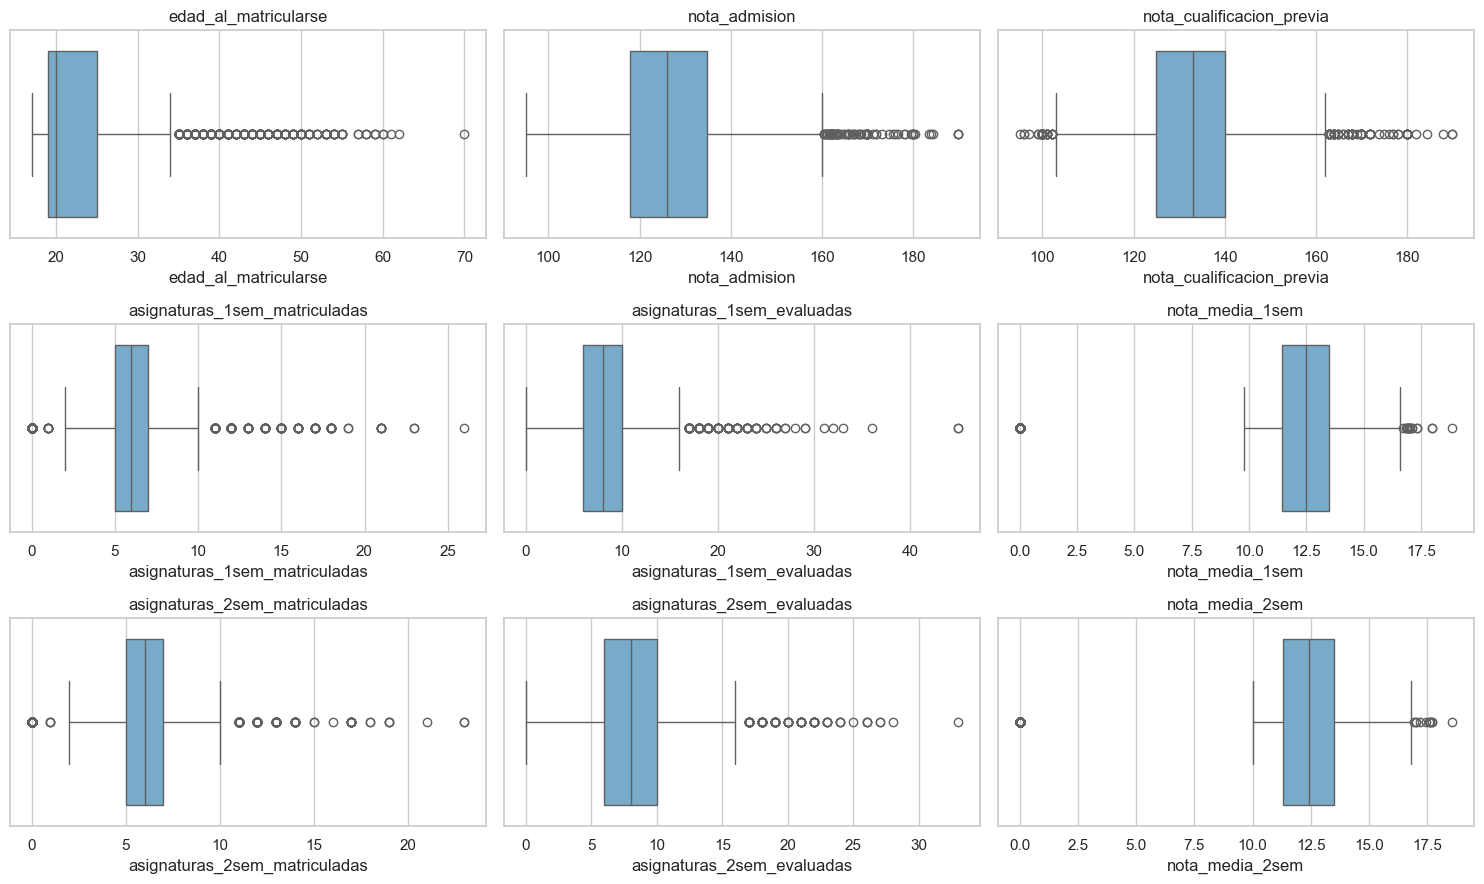

In [14]:
def resumen_outliers_iqr(df, columns=None, whisker_width=1.5):
    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()

    filas = []
    for col in columns:
        serie = df[col].dropna()
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - whisker_width * iqr
        upper = q3 + whisker_width * iqr
        mask = (serie < lower) | (serie > upper)
        filas.append(
            {
                "columna": col,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "limite_inferior": lower,
                "limite_superior": upper,
                "n_outliers": int(mask.sum()),
                "pct_outliers": round(100 * mask.mean(), 2),
            }
        )
    return pd.DataFrame(filas).sort_values("n_outliers", ascending=False)


def resumen_percentiles(df, columns=None, lower=0.01, upper=0.99):
    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()

    filas = []
    for col in columns:
        serie = df[col].dropna()
        filas.append(
            {
                "columna": col,
                "min": serie.min(),
                f"p{int(lower*100)}": serie.quantile(lower),
                "mediana": serie.median(),
                f"p{int(upper*100)}": serie.quantile(upper),
                "max": serie.max(),
            }
        )
    return pd.DataFrame(filas)


def plot_boxplots_numericas(df, columns, ncols=3, figsize=(14, 10)):
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, columns):
        sns.boxplot(x=df[col], ax=ax, color="#6baed6")
        ax.set_title(col)

    for ax in axes[len(columns):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

columnas_outliers = [
    "edad_al_matricularse",
    "nota_admision",
    "nota_cualificacion_previa",
    "asignaturas_1sem_matriculadas",
    "asignaturas_1sem_evaluadas",
    "nota_media_1sem",
    "asignaturas_2sem_matriculadas",
    "asignaturas_2sem_evaluadas",
    "nota_media_2sem",
]

display(resumen_outliers_iqr(df_ceros_tratados, columnas_outliers))
display(resumen_percentiles(df_ceros_tratados, columnas_outliers))
plot_boxplots_numericas(df_ceros_tratados, columnas_outliers, ncols=3, figsize=(15, 9))

## Decisiones del EDA

- Leer el CSV con `sep=";"`.
- Convertir `en_blanco` a missing.
- Mantener `desconocido` como categoria en la version principal.
- No borrar filas por `evaluadas > matriculadas`.
- Convertir a missing solo las notas 0 con 0 evaluaciones.
- No eliminar outliers de forma general.
